# 01 · Data Exploration

**Project:** CVaR Portfolio Backtest — Malta Accessible ETFs  
**Scope:** Inspect the cleaned EUR-aligned price panel and daily log-return series.

---

**Universe (6 ETFs):**

| ID | Name | Region | Asset Class | Native CCY |
|----|------|--------|-------------|------------|
| ETF01 | iShares Core S&P 500 UCITS (CSPX) | US | Equity | USD |
| ETF02 | iShares Core MSCI Europe UCITS (SMEA) | Europe | Equity | GBP |
| ETF03 | iShares Core MSCI Japan IMI UCITS (IJPA) | Japan | Equity | EUR |
| ETF04 | iShares Core MSCI EM IMI UCITS (EMIM) | Emerging Markets | Equity | EUR |
| ETF05 | iShares $ Treasury Bond 7-10yr UCITS (CBU0) | US Treasury | Fixed Income | USD |
| ETF06 | iShares € Govt Bond 7-10yr UCITS (SXRQ) | Euro Government | Fixed Income | EUR |

All prices have been converted to **EUR** before return computation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make project root importable when running from notebooks/
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import (
    compute_and_save_stats,
    correlation_matrix,
    price_summary_stats,
    return_summary_stats,
)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
})

DATA    = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

ETF_LABELS = {
    "ETF01": "ETF01 S&P 500",
    "ETF02": "ETF02 MSCI Europe",
    "ETF03": "ETF03 MSCI Japan",
    "ETF04": "ETF04 MSCI EM",
    "ETF05": "ETF05 US Treasury",
    "ETF06": "ETF06 Euro Govt Bond",
}

EQUITY_COLS  = ["ETF01", "ETF02", "ETF03", "ETF04"]
BOND_COLS    = ["ETF05", "ETF06"]
ALL_ETF_COLS = EQUITY_COLS + BOND_COLS

## 1 · Load Data

In [2]:
prices  = pd.read_csv(DATA / "etf_prices_panel_eur.csv", parse_dates=["date"])
returns = pd.read_csv(DATA / "etf_returns_log.csv",      parse_dates=["date"])

print("EUR price panel")
print(f"  Shape      : {prices.shape}")
print(f"  First date : {prices['date'].min().date()}")
print(f"  Last date  : {prices['date'].max().date()}")
print()
print("Log-return panel")
print(f"  Shape      : {returns.shape}")
print(f"  First date : {returns['date'].min().date()}")
print(f"  Last date  : {returns['date'].max().date()}")

EUR price panel
  Shape      : (2499, 7)
  First date : 2016-01-04
  Last date  : 2025-12-30

Log-return panel
  Shape      : (2498, 7)
  First date : 2016-01-05
  Last date  : 2025-12-30


## 2 · Data Integrity Check

In [3]:
print("Missing values — EUR price panel:")
print(prices.isna().sum())
print()
print("Missing values — log returns:")
print(returns.isna().sum())
print()
print("Duplicate dates in price panel :", prices['date'].duplicated().sum())
print("Duplicate dates in return panel:", returns['date'].duplicated().sum())

Missing values — EUR price panel:
date     0
ETF01    0
ETF02    0
ETF03    0
ETF04    0
ETF05    0
ETF06    0
dtype: int64

Missing values — log returns:
date     0
ETF01    0
ETF02    0
ETF03    0
ETF04    0
ETF05    0
ETF06    0
dtype: int64

Duplicate dates in price panel : 0
Duplicate dates in return panel: 0


In [4]:
# One date was dropped during FX alignment (Yahoo Finance FX data gap)
DROPPED_DATE = pd.Timestamp("2019-05-22")
print(f"Note: {DROPPED_DATE.date()} was removed during FX alignment.")
print("  Cause: no USDEUR or GBPEUR rate available for that date in Yahoo Finance.")
print("  Impact: 1 row removed; price panel has 2,499 rows (from 2,500 common dates).")

Note: 2019-05-22 was removed during FX alignment.
  Cause: no USDEUR or GBPEUR rate available for that date in Yahoo Finance.
  Impact: 1 row removed; price panel has 2,499 rows (from 2,500 common dates).


## 3 · Summary Statistics — EUR Prices

In [5]:
price_stats = price_summary_stats(prices)
price_stats.round(2)

,ETF01,ETF02,ETF03,ETF04,ETF05,ETF06
count,2499.00,2499.00,2499.00,2499.00,2499.00,2499.00
mean,344.35,59.69,40.81,27.05,131.80,157.65
std,133.84,13.88,7.34,4.57,9.04,10.93
min,149.97,36.97,25.10,15.68,108.14,136.18
25%,224.73,48.94,35.32,23.87,127.01,150.74
50%,311.02,56.29,40.24,26.98,131.45,156.04
75%,423.74,68.29,44.90,30.83,138.02,169.07
max,635.49,94.23,59.71,39.21,157.48,177.49


## 4 · Summary Statistics — Daily Log Returns

In [6]:
ret_stats = return_summary_stats(returns)
ret_stats.round(6)

,ETF01,ETF02,ETF03,ETF04,ETF05,ETF06
count,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000,2498.000000
mean,0.000522,0.000317,0.000269,0.000305,0.000020,0.000006
std,0.011117,0.010533,0.010447,0.011556,0.005996,0.003757
min,-0.093258,-0.108064,-0.119848,-0.120763,-0.039517,-0.020327
max,0.077890,0.049107,0.070133,0.068714,0.040777,0.023819
skewness,-0.611798,-0.869901,-0.790003,-0.901248,-0.049919,0.270708
kurtosis,6.318654,7.744675,10.366148,8.558295,3.469880,4.752075
ann_mean,0.131456,0.079816,0.067702,0.076965,0.004991,0.001578
ann_volatility,0.176480,0.167211,0.165836,0.183444,0.095180,0.059643


## 5 · Correlation Matrix — Daily Log Returns

In [7]:
corr = correlation_matrix(returns)
corr.round(4)

,ETF01,ETF02,ETF03,ETF04,ETF05,ETF06
ETF01,1.0000,0.6742,0.6004,0.6516,0.2110,0.0378
ETF02,0.6742,1.0000,0.5450,0.6102,-0.0139,0.0229
ETF03,0.6004,0.5450,1.0000,0.6712,-0.0386,0.0966
ETF04,0.6516,0.6102,0.6712,1.0000,-0.0786,0.0433
ETF05,0.2110,-0.0139,-0.0386,-0.0786,1.0000,0.4140
ETF06,0.0378,0.0229,0.0966,0.0433,0.4140,1.0000


## 6 · Charts

### 6.1 EUR Price Panel

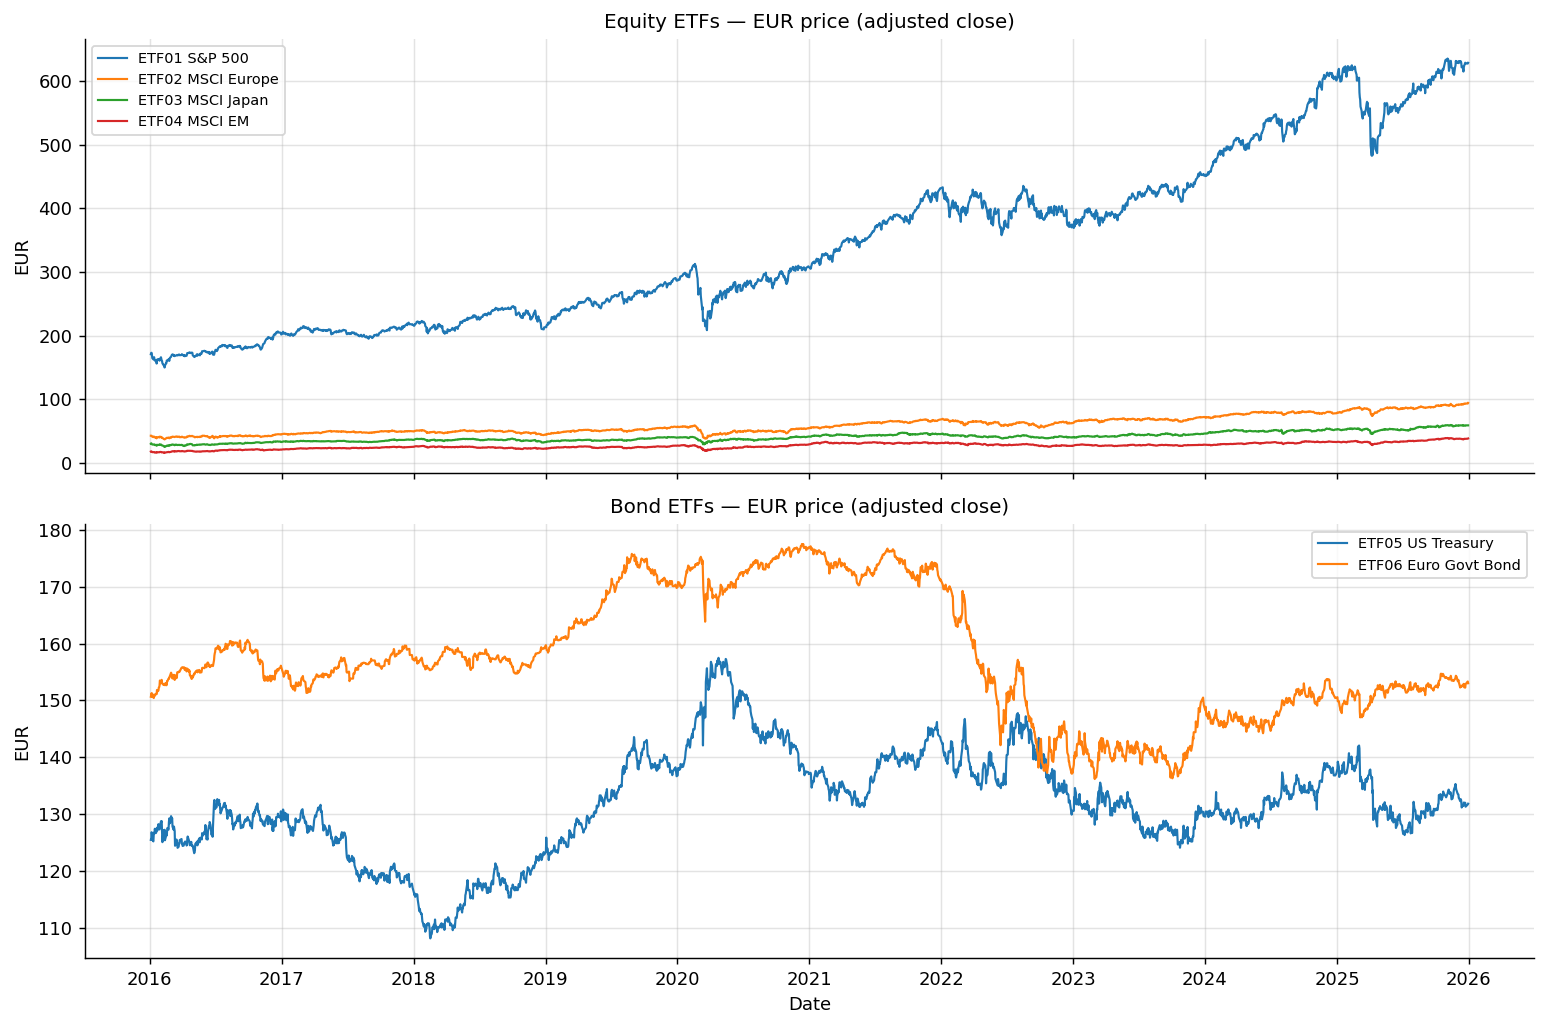

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
for col in EQUITY_COLS:
    ax.plot(prices["date"], prices[col], label=ETF_LABELS[col], linewidth=1.2)
ax.set_title("Equity ETFs — EUR price (adjusted close)", fontsize=11)
ax.set_ylabel("EUR")
ax.legend(fontsize=8)

ax = axes[1]
for col in BOND_COLS:
    ax.plot(prices["date"], prices[col], label=ETF_LABELS[col], linewidth=1.2)
ax.set_title("Bond ETFs — EUR price (adjusted close)", fontsize=11)
ax.set_ylabel("EUR")
ax.set_xlabel("Date")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "01_eur_price_panel.png", bbox_inches="tight")
plt.show()

### 6.2 Cumulative Growth of €1 Invested

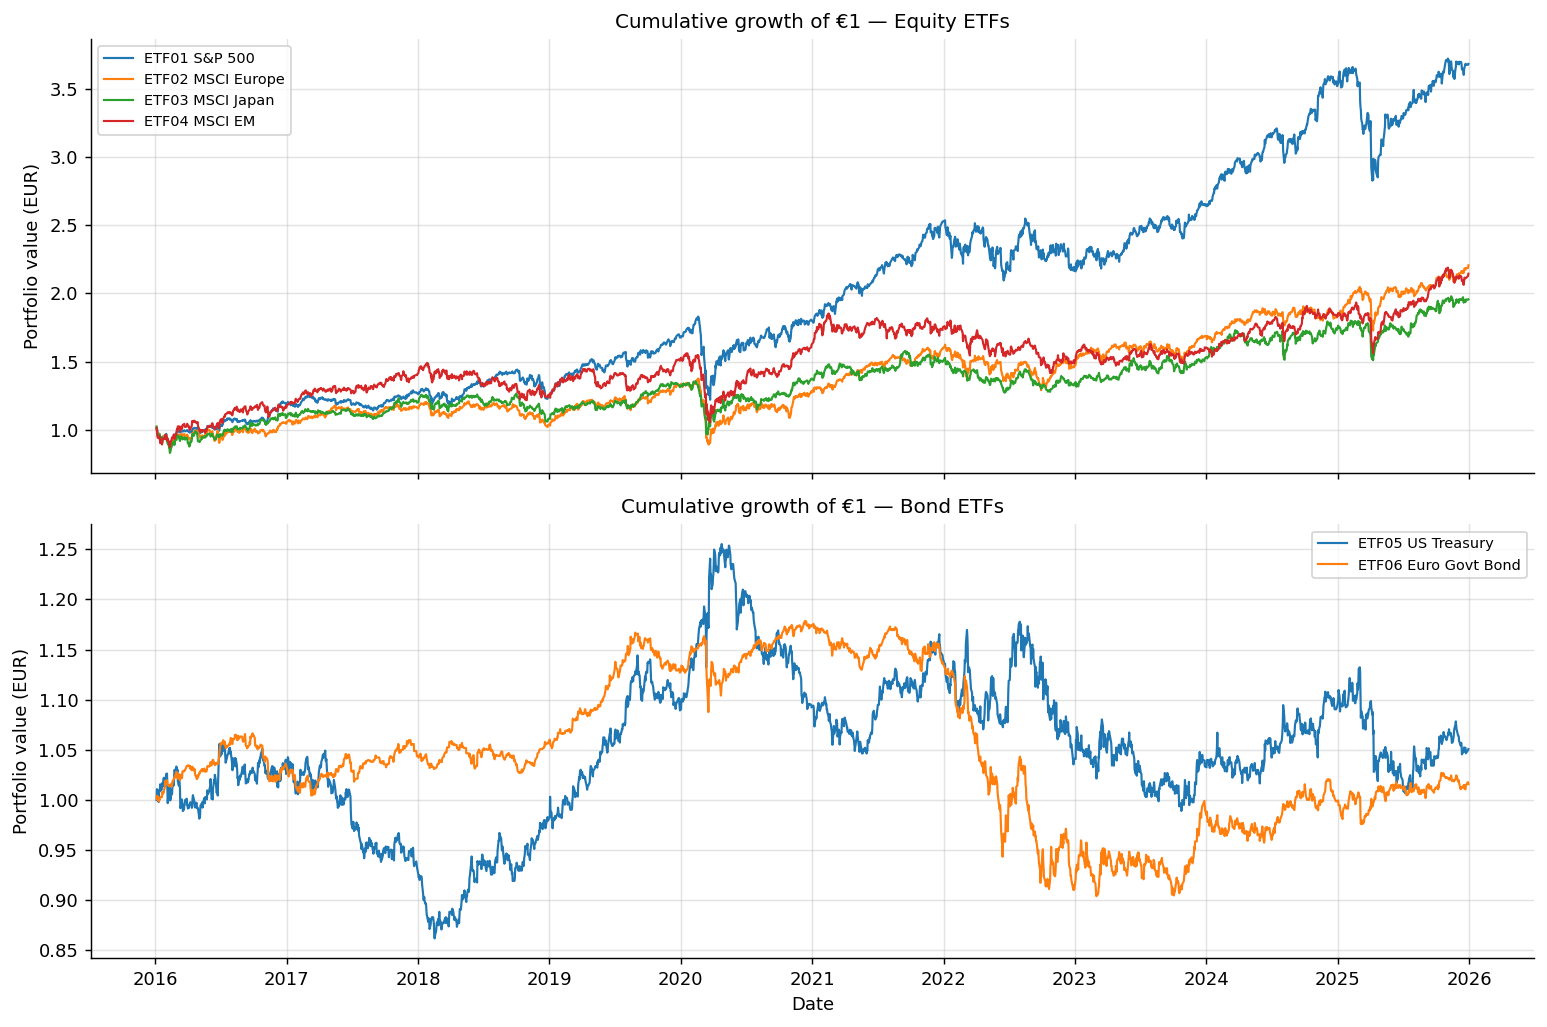

In [9]:
# Cumulative return = exp(sum of log returns)
cum_growth = np.exp(returns[ALL_ETF_COLS].cumsum())
cum_growth.insert(0, "date", returns["date"])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
for col in EQUITY_COLS:
    ax.plot(cum_growth["date"], cum_growth[col], label=ETF_LABELS[col], linewidth=1.2)
ax.set_title("Cumulative growth of \u20ac1 — Equity ETFs", fontsize=11)
ax.set_ylabel("Portfolio value (EUR)")
ax.legend(fontsize=8)

ax = axes[1]
for col in BOND_COLS:
    ax.plot(cum_growth["date"], cum_growth[col], label=ETF_LABELS[col], linewidth=1.2)
ax.set_title("Cumulative growth of \u20ac1 — Bond ETFs", fontsize=11)
ax.set_ylabel("Portfolio value (EUR)")
ax.set_xlabel("Date")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "02_cumulative_growth.png", bbox_inches="tight")
plt.show()

### 6.3 Return Correlation Heatmap

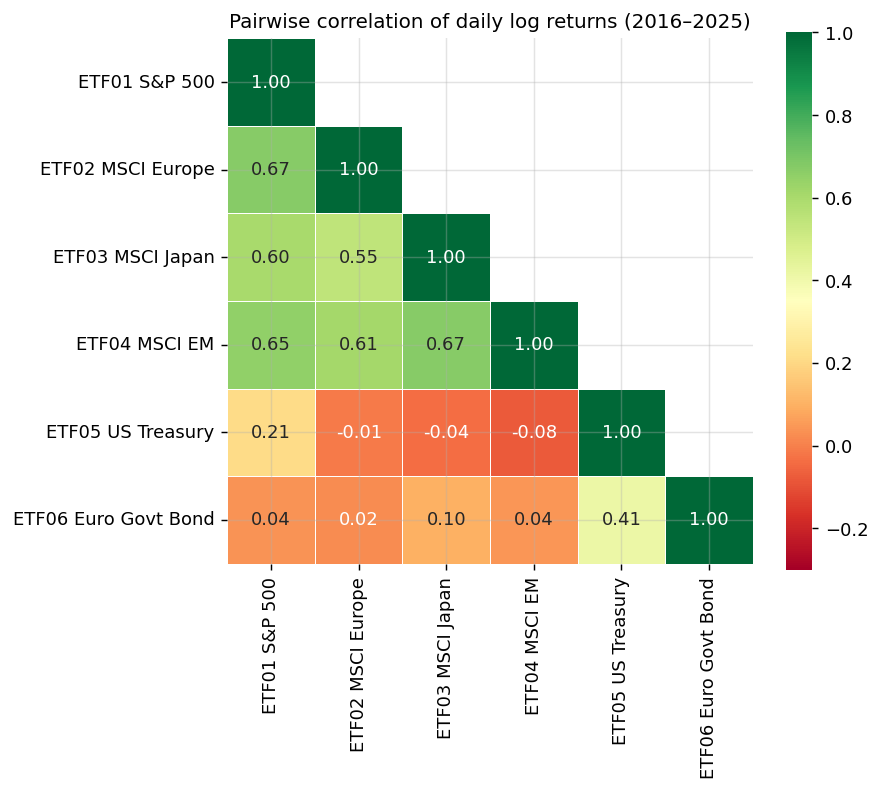

In [10]:
labels = [ETF_LABELS[c] for c in corr.columns]
mask   = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-0.3,
    vmax=1.0,
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    square=True,
)
ax.set_title("Pairwise correlation of daily log returns (2016\u20132025)", fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / "03_correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 7 · Interpretation

### Relative Volatility

Equity ETFs carry annualised EUR volatility of roughly 15–18%, while bond ETFs sit at 6–9.5%. The equity ETFs denominated in USD (ETF01, ETF05) and GBP (ETF02) absorb additional FX risk once converted to EUR, which is already reflected in those volatility figures.

ETF05 (US Treasuries, USD) has notably higher volatility than ETF06 (Euro Govt Bonds, EUR) — partly because the 7–10yr USD bond duration is similar, but the USD/EUR rate adds noise. ETF06 is the lowest-volatility series in the universe (~6% p.a.), which should serve as a stabiliser in the portfolio.

### Diversification Patterns

The four equity ETFs are strongly correlated with each other (\u03c1 \u2248 0.55\u20130.67). Cross-regional diversification still reduces risk, but these ETFs are not independent return sources. During global risk-off events (COVID 2020, rate shock 2022), correlations tend to spike further toward 1.

The most diversifying combination in the equity block is ETF03 (Japan) paired with any of the others, which shows the lowest pairwise correlations among equities.

### Bond–Equity Relationship

Both bond ETFs show near-zero or slightly negative correlation with equities — the classic diversification property. ETF05 (US Treasury) is mildly negative against European and EM equities, consistent with flight-to-quality dynamics. ETF06 (Euro Govt Bond) sits close to zero, reflecting the 2022 episode where rising rates sold off both equities and bonds simultaneously, dampening the traditional negative correlation.

ETF05 and ETF06 share a moderate positive correlation (\u03c1 \u2248 0.41): both are interest-rate sensitive, and both react in the same direction to global rate moves.

### Return Distribution

All equity series show **negative skewness** (larger downside tails) and **excess kurtosis well above 3** — fat-tailed distributions. Bond returns are more symmetric but still leptokurtic. This validates using CVaR rather than variance as the risk measure: CVaR is directly sensitive to the tail events that standard deviation understates.

### Plausibility for Backtesting

The 2016\u20132025 window is well-chosen: it covers a sustained equity bull market (2016\u20132019), the COVID crash and recovery (2020), and the 2022 rate-shock bear market. The EUR-converted prices incorporate realistic FX dynamics. No structural breaks, extreme outliers, or data anomalies are visible. The one dropped date (2019-05-22) is inconsequential. The data is ready for rolling-window CVaR optimisation.

In [11]:
# Persist all stats CSVs (idempotent)
compute_and_save_stats(prices, returns)
print("All stats files saved to data/processed/")

Saved:
  data/processed/summary_stats_prices.csv
  data/processed/summary_stats_returns.csv
  data/processed/correlation_matrix.csv
  data/processed/covariance_matrix.csv
All stats files saved to data/processed/
